# 환경설정

In [ ]:
# facemap_3dmm 포함 qai_hub_models 설치
!pip install -q 'qai-hub-models[facemap-3dmm]'

# InsightFace + ONNX Runtime GPU
!pip install -q insightface onnxruntime-gpu opencv-python-headless

print('✅ 설치 완료')

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 103.9/103.9 kB 6.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 148.8/148.8 kB 11.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.2/68.2 kB 7.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 503.6/503.6 kB 35.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 195.4/195.4 kB 17.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 798.3/798.3 kB 58.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.9/64.9 kB 6.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.8/42.8 MB 28.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.7/117.7 kB 13.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.6/9.6 MB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 139.2/139.2 kB 15.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.3/13.3 MB 118.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [ ]:
import os

os.makedirs('/root/.insightface/models', exist_ok=True)
INSWAPPER_PATH = '/root/.insightface/models/inswapper_128.onnx'

if not os.path.exists(INSWAPPER_PATH):
    print('⬇ inswapper_128.onnx 다운로드 중... (~500MB)')
    !wget -q --show-progress \
        -O {INSWAPPER_PATH} \
        https://huggingface.co/ezioruan/inswapper_128.onnx/resolve/main/inswapper_128.onnx
    print('✅ 다운로드 완료')
else:
    print('✅ inswapper_128.onnx 이미 존재')

⬇ inswapper_128.onnx 다운로드 중... (~500MB)
/root/.insightface/ 100%[===================>] 528.58M   190MB/s    in 2.8s    
✅ 다운로드 완료


# 모델 초기화 및 전처리 함수

In [ ]:
import torch
import numpy as np
import cv2
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from qai_hub_models.models.facemap_3dmm import Model as FaceMap3DMM

print('facemap_3dmm 로드 중...')
facemap_model = FaceMap3DMM.from_pretrained()
facemap_model.eval()

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
facemap_model = facemap_model.to(device)

print(f'✅ facemap_3dmm 로드 완료 | device: {device}')
print(f'   입력 spec: {facemap_model.get_input_spec()}')

facemap_3dmm 로드 중...


✅ facemap_3dmm 로드 완료 | device: cuda
   입력 spec: {'image': ((1, 3, 128, 128), 'float32')}


In [ ]:
import insightface
from insightface.app import FaceAnalysis

face_app = FaceAnalysis(
    name='buffalo_l',
    providers=['CUDAExecutionProvider', 'CPUExecutionProvider']
)
face_app.prepare(ctx_id=0, det_size=(640, 640))

swapper = insightface.model_zoo.get_model(
    INSWAPPER_PATH, download=False
)

print('✅ InsightFace 초기화 완료')

download_path: /root/.insightface/models/buffalo_l


100%|██████████| 281857/281857 [00:03<00:00, 73938.62KB/s]


Applied providers: ['CUDAExecutionProvider', 'CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}, 'CUDAExecutionProvider': {'sdpa_kernel': '0', 'use_tf32': '1', 'fuse_conv_bias': '0', 'prefer_nhwc': '0', 'tunable_op_max_tuning_duration_ms': '0', 'enable_skip_layer_norm_strict_mode': '0', 'tunable_op_tuning_enable': '0', 'tunable_op_enable': '0', 'use_ep_level_unified_stream': '0', 'device_id': '0', 'has_user_compute_stream': '0', 'gpu_external_empty_cache': '0', 'cudnn_conv_algo_search': 'EXHAUSTIVE', 'cudnn_conv1d_pad_to_nc1d': '0', 'gpu_mem_limit': '18446744073709551615', 'gpu_external_alloc': '0', 'gpu_external_free': '0', 'arena_extend_strategy': 'kNextPowerOfTwo', 'do_copy_in_default_stream': '1', 'enable_cuda_graph': '0', 'user_compute_stream': '0', 'cudnn_conv_use_max_workspace': '1'}}
find model: /root/.insightface/models/buffalo_l/1k3d68.onnx landmark_3d_68 ['None', 3, 192, 192] 0.0 1.0
Applied providers: ['CUDAExecutionProvider', 'CPUExecutionProvider'], with o

In [ ]:
INPUT_SIZE = 128

def preprocess_for_facemap(img_bgr, face_bbox=None):
    h, w = img_bgr.shape[:2]
    if face_bbox is not None:
        x1, y1, x2, y2 = [int(v) for v in face_bbox]
        pad_x = int((x2 - x1) * 0.2)
        pad_y = int((y2 - y1) * 0.2)
        x1 = max(0, x1 - pad_x)
        y1 = max(0, y1 - pad_y)
        x2 = min(w, x2 + pad_x)
        y2 = min(h, y2 + pad_y)
        crop = img_bgr[y1:y2, x1:x2]
        offset_xy = (x1, y1)
        crop_wh   = (x2 - x1, y2 - y1)
    else:
        crop = img_bgr
        offset_xy = (0, 0)
        crop_wh   = (w, h)

    resized = cv2.resize(crop, (INPUT_SIZE, INPUT_SIZE))
    scale_xy = (crop_wh[0] / INPUT_SIZE, crop_wh[1] / INPUT_SIZE)
    rgb = cv2.cvtColor(resized, cv2.COLOR_BGR2RGB).astype(np.float32) / 255.0
    normalized = (rgb - 0.5) / 0.5
    tensor = torch.from_numpy(normalized.transpose(2, 0, 1)).unsqueeze(0).to(device)
    return tensor, scale_xy, offset_xy


def postprocess_landmarks(output, scale_xy, offset_xy):
    if isinstance(output, (tuple, list)):
        lm_tensor = output[0]
    else:
        lm_tensor = output
    lm = lm_tensor.detach().cpu().numpy()
    lm = lm.reshape(-1, lm.shape[-1]) if lm.ndim > 2 else lm
    xy = lm[:, :2]
    sx, sy = scale_xy
    ox, oy = offset_xy
    xy[:, 0] = xy[:, 0] * sx + ox
    xy[:, 1] = xy[:, 1] * sy + oy
    return xy.astype(np.float32)


def landmarks_to_5kps(landmarks_2d):
    n = len(landmarks_2d)
    if n == 68:
        right_eye   = landmarks_2d[36:42].mean(axis=0)
        left_eye    = landmarks_2d[42:48].mean(axis=0)
        nose_tip    = landmarks_2d[30]
        right_mouth = landmarks_2d[48]
        left_mouth  = landmarks_2d[54]
    else:
        if n < 5:
            return np.full((5, 2), np.nan, dtype=np.float32)
        def idx(ratio): return int(n * ratio)
        right_eye   = landmarks_2d[idx(0.28):idx(0.38)].mean(axis=0)
        left_eye    = landmarks_2d[idx(0.38):idx(0.48)].mean(axis=0)
        nose_tip    = landmarks_2d[idx(0.44)]
        right_mouth = landmarks_2d[idx(0.60)]
        left_mouth  = landmarks_2d[idx(0.70)]
    return np.array([right_eye, left_eye, nose_tip, right_mouth, left_mouth], dtype=np.float32)


def is_valid_kps_5(kps):
    if kps is None or kps.shape != (5, 2) or np.any(np.isnan(kps)) or np.any(np.isinf(kps)):
        return False
    return True


def extract_landmarks_from_frame(frame_bgr, insightface_face=None):
    """
    단일 프레임에서 facemap_3dmm 랜드마크 추출
    Returns: dict with landmarks_2d, kps_5, detected
    """
    result = dict(landmarks_2d=None, kps_5=None, detected=False)
    bbox = None
    if insightface_face is not None and hasattr(insightface_face, 'bbox'):
        bbox = insightface_face.bbox

    tensor, scale_xy, offset_xy = preprocess_for_facemap(frame_bgr, face_bbox=bbox)
    with torch.no_grad():
        output = facemap_model(tensor)
    landmarks = postprocess_landmarks(output, scale_xy, offset_xy)
    kps_5 = landmarks_to_5kps(landmarks)
    result.update(dict(landmarks_2d=landmarks, kps_5=kps_5, detected=True))
    return result


print('✅ 전처리 / 후처리 / 변환 함수 정의 완료')

✅ 전처리 / 후처리 / 변환 함수 정의 완료


# STEP 1 : 소스 이미지 & 타겟 영상 업로드

In [ ]:
from google.colab import files
import os

print('📁 소스 이미지 업로드 (얼굴을 가져올 이미지)')
src_upload = files.upload()
src_path = list(src_upload.keys())[0]

print('\n📁 타겟 영상 업로드 (얼굴을 교체할 동영상)')
vid_upload = files.upload()
video_path = list(vid_upload.keys())[0]

src_img = cv2.imread(src_path)
assert src_img is not None, '소스 이미지 로드 실패'

# 영상 기본 정보 확인
cap = cv2.VideoCapture(video_path)
fps        = cap.get(cv2.CAP_PROP_FPS)
total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
width      = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height     = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
cap.release()

print(f'\n✅ 영상 정보')
print(f'   - 경로     : {video_path}')
print(f'   - 해상도   : {width}x{height}')
print(f'   - FPS      : {fps:.2f}')
print(f'   - 총 프레임: {total_frames}')
print(f'   - 재생시간 : {total_frames/fps:.1f}초')

# 작업 폴더 생성
WORK_DIR       = '/content/video_faceswap'
FRAMES_DIR     = f'{WORK_DIR}/frames_original'   # 원본 프레임
LANDMARK_DIR   = f'{WORK_DIR}/landmarks'          # 랜드마크 txt
SWAPPED_DIR    = f'{WORK_DIR}/frames_swapped'     # 스왑된 프레임

for d in [WORK_DIR, FRAMES_DIR, LANDMARK_DIR, SWAPPED_DIR]:
    os.makedirs(d, exist_ok=True)

print(f'\n✅ 작업 디렉토리 생성 완료: {WORK_DIR}')

📁 소스 이미지 업로드 (얼굴을 가져올 이미지)


Saving cortis.jpeg to cortis.jpeg

📁 타겟 영상 업로드 (얼굴을 교체할 동영상)


Saving d0.mp4 to d0.mp4

✅ 영상 정보
   - 경로     : d0.mp4
   - 해상도   : 512x512
   - FPS      : 25.00
   - 총 프레임: 78
   - 재생시간 : 3.1초

✅ 작업 디렉토리 생성 완료: /content/video_faceswap


# STEP 2 : 영상 → 프레임 분리

In [ ]:
import time

print('🎬 영상을 프레임 단위로 분리 중...')
t0 = time.time()

cap = cv2.VideoCapture(video_path)
frame_idx = 0

while True:
    ret, frame = cap.read()
    if not ret:
        break
    # 파일명: frame_000000.jpg (6자리 제로패딩)
    frame_path = f'{FRAMES_DIR}/frame_{frame_idx:06d}.jpg'
    cv2.imwrite(frame_path, frame, [cv2.IMWRITE_JPEG_QUALITY, 95])
    frame_idx += 1

    if frame_idx % 100 == 0:
        print(f'  {frame_idx}/{total_frames} 프레임 저장...')

cap.release()
print(f'✅ 프레임 분리 완료: {frame_idx}장 | {time.time()-t0:.1f}초')

🎬 영상을 프레임 단위로 분리 중...
✅ 프레임 분리 완료: 78장 | 0.4초


# STEP 3 : 각 프레임에서 랜드마크 추출 → txt 저장

In [ ]:
import glob

frame_paths = sorted(glob.glob(f'{FRAMES_DIR}/frame_*.jpg'))
print(f'📍 총 {len(frame_paths)}개 프레임에서 랜드마크 추출 시작')
print('   (랜드마크 txt는 landmarks/ 폴더에 프레임별로 저장됩니다)\n')

t0 = time.time()
no_face_frames = []  # 얼굴 감지 실패 프레임 목록

for i, fpath in enumerate(frame_paths):
    frame_bgr = cv2.imread(fpath)
    frame_name = os.path.splitext(os.path.basename(fpath))[0]  # e.g. frame_000000
    txt_path = f'{LANDMARK_DIR}/{frame_name}.txt'

    # InsightFace로 얼굴 감지 (bbox 참조용)
    tgt_faces = face_app.get(frame_bgr)
    insightface_face = tgt_faces[0] if tgt_faces else None

    # facemap_3dmm으로 랜드마크 추출
    face_info = extract_landmarks_from_frame(frame_bgr, insightface_face=insightface_face)

    # ── txt 저장 포맷 ──────────────────────────────────────────────
    # 헤더: # frame_idx, face_detected, num_landmarks
    # 본문: x y  (한 줄에 한 점)
    # kps5: 마지막 5줄 (# kps5 섹션)
    # ──────────────────────────────────────────────────────────────
    with open(txt_path, 'w') as f:
        face_detected = int(len(tgt_faces) > 0)
        lm = face_info['landmarks_2d']
        kps = face_info['kps_5']
        num_lm = len(lm) if lm is not None else 0

        f.write(f'# frame_idx={i} face_detected={face_detected} num_landmarks={num_lm}\n')

        # 랜드마크 좌표
        f.write('# landmarks x y\n')
        if lm is not None:
            for x, y in lm:
                f.write(f'{x:.4f} {y:.4f}\n')

        # 5-point keypoints
        f.write('# kps5 x y\n')
        if kps is not None:
            for x, y in kps:
                f.write(f'{x:.4f} {y:.4f}\n')

        # InsightFace bbox (있으면)
        f.write('# insightface_bbox x1 y1 x2 y2\n')
        if tgt_faces:
            bbox = tgt_faces[0].bbox
            f.write(f'{bbox[0]:.4f} {bbox[1]:.4f} {bbox[2]:.4f} {bbox[3]:.4f}\n')

    if not tgt_faces:
        no_face_frames.append(i)

    if (i + 1) % 50 == 0:
        elapsed = time.time() - t0
        eta = elapsed / (i + 1) * (len(frame_paths) - i - 1)
        print(f'  [{i+1}/{len(frame_paths)}] {elapsed:.0f}초 경과 | ETA {eta:.0f}초')

print(f'\n✅ 랜드마크 추출 완료 | 총 {time.time()-t0:.1f}초')
print(f'   얼굴 미감지 프레임: {len(no_face_frames)}개')
if no_face_frames:
    print(f'   미감지 프레임 인덱스: {no_face_frames[:20]}{'...' if len(no_face_frames)>20 else ''}')
print(f'   랜드마크 저장 위치: {LANDMARK_DIR}')

📍 총 78개 프레임에서 랜드마크 추출 시작
   (랜드마크 txt는 landmarks/ 폴더에 프레임별로 저장됩니다)

  [50/78] 2초 경과 | ETA 1초

✅ 랜드마크 추출 완료 | 총 3.1초
   얼굴 미감지 프레임: 0개
   랜드마크 저장 위치: /content/video_faceswap/landmarks


# STEP 4 : txt 랜드마크 로드 → 프레임별 얼굴 스왑

In [ ]:
def load_landmarks_from_txt(txt_path):
    """
    txt 파일에서 랜드마크 정보를 읽어 반환
    Returns:
        dict: landmarks_2d, kps_5, insightface_bbox, face_detected
    """
    result = dict(landmarks_2d=None, kps_5=None, insightface_bbox=None, face_detected=False)
    if not os.path.exists(txt_path):
        return result

    with open(txt_path, 'r') as f:
        lines = f.readlines()

    mode = None
    lm_pts, kps_pts, bbox_pts = [], [], []

    for line in lines:
        line = line.strip()
        if not line:
            continue
        if line.startswith('# frame_idx'):
            # # frame_idx=0 face_detected=1 num_landmarks=68
            parts = line.split()
            for p in parts:
                if p.startswith('face_detected='):
                    result['face_detected'] = bool(int(p.split('=')[1]))
            continue
        if line == '# landmarks x y':
            mode = 'landmarks'
            continue
        if line == '# kps5 x y':
            mode = 'kps5'
            continue
        if line == '# insightface_bbox x1 y1 x2 y2':
            mode = 'bbox'
            continue
        if line.startswith('#'):
            mode = None
            continue

        vals = list(map(float, line.split()))
        if mode == 'landmarks' and len(vals) == 2:
            lm_pts.append(vals)
        elif mode == 'kps5' and len(vals) == 2:
            kps_pts.append(vals)
        elif mode == 'bbox' and len(vals) == 4:
            bbox_pts = vals

    if lm_pts:
        result['landmarks_2d'] = np.array(lm_pts, dtype=np.float32)
    if kps_pts:
        result['kps_5'] = np.array(kps_pts, dtype=np.float32)
    if bbox_pts:
        result['insightface_bbox'] = bbox_pts
    return result


print('✅ load_landmarks_from_txt 함수 정의 완료')

# 소스 얼굴 임베딩 추출 (1회만 실행)
src_faces = face_app.get(src_img)
if not src_faces:
    raise ValueError('❌ 소스 이미지에서 얼굴 감지 실패')
src_face = src_faces[0]
print(f'✅ 소스 얼굴 임베딩 추출 완료 (총 {len(src_faces)}개 얼굴 감지)')

✅ load_landmarks_from_txt 함수 정의 완료
✅ 소스 얼굴 임베딩 추출 완료 (총 1개 얼굴 감지)


In [ ]:
print('🎭 프레임별 얼굴 스왑 시작...')
print('   (txt 랜드마크 로드 → 얼굴 스왑 → swapped 프레임 저장)\n')

t0 = time.time()
skipped = 0

for i, fpath in enumerate(frame_paths):
    frame_bgr = cv2.imread(fpath)
    frame_name = os.path.splitext(os.path.basename(fpath))[0]
    txt_path    = f'{LANDMARK_DIR}/{frame_name}.txt'
    out_path    = f'{SWAPPED_DIR}/{frame_name}.jpg'

    # ── 랜드마크 txt 로드 ────────────────────────────────────────
    lm_data = load_landmarks_from_txt(txt_path)

    # ── InsightFace 얼굴 감지 (bbox 기반 재감지) ─────────────────
    # kps 주입을 위해 live face object 가 필요하므로 face_app.get() 재호출
    tgt_faces = face_app.get(frame_bgr)

    if not tgt_faces:
        # 얼굴 미감지 → 원본 프레임 그대로 저장
        cv2.imwrite(out_path, frame_bgr, [cv2.IMWRITE_JPEG_QUALITY, 95])
        skipped += 1
        continue

    # ── txt에서 로드한 kps_5를 InsightFace face 객체에 주입 ───────
    result = frame_bgr.copy()
    for j, tgt_face in enumerate(tgt_faces):
        if j == 0 and lm_data['kps_5'] is not None and is_valid_kps_5(lm_data['kps_5']):
            # txt 랜드마크 기반 kps 주입
            tgt_face.kps = lm_data['kps_5'].astype(np.float32)
        elif hasattr(tgt_face, 'kps') and is_valid_kps_5(tgt_face.kps):
            # txt가 없으면 InsightFace 자체 kps 사용
            pass
        else:
            continue  # 유효한 kps 없으면 건너뜀

        result = swapper.get(result, tgt_face, src_face, paste_back=True)

    cv2.imwrite(out_path, result, [cv2.IMWRITE_JPEG_QUALITY, 95])

    if (i + 1) % 50 == 0:
        elapsed = time.time() - t0
        eta = elapsed / (i + 1) * (len(frame_paths) - i - 1)
        print(f'  [{i+1}/{len(frame_paths)}] {elapsed:.0f}초 경과 | ETA {eta:.0f}초 | 스킵 {skipped}개')

print(f'\n✅ 얼굴 스왑 완료 | 총 {time.time()-t0:.1f}초')
print(f'   처리 프레임: {len(frame_paths) - skipped}개 | 스킵(얼굴없음): {skipped}개')
print(f'   저장 위치: {SWAPPED_DIR}')

🎭 프레임별 얼굴 스왑 시작...
   (txt 랜드마크 로드 → 얼굴 스왑 → swapped 프레임 저장)

  [50/78] 6초 경과 | ETA 4초 | 스킵 0개

✅ 얼굴 스왑 완료 | 총 10.2초
   처리 프레임: 78개 | 스킵(얼굴없음): 0개
   저장 위치: /content/video_faceswap/frames_swapped


# STEP 5 : 스왑 프레임 → 영상 재합성 (오디오 없음)

In [ ]:
OUTPUT_VIDEO = f'{WORK_DIR}/result_faceswap.mp4'

swapped_paths = sorted(glob.glob(f'{SWAPPED_DIR}/frame_*.jpg'))
print(f'🎬 {len(swapped_paths)}개 프레임을 영상으로 합성 중...')
print(f'   FPS: {fps:.2f} | 해상도: {width}x{height}')

# mp4v 코덱으로 VideoWriter 생성
fourcc = cv2.VideoWriter_fourcc(*'mp4v')
writer = cv2.VideoWriter(OUTPUT_VIDEO, fourcc, fps, (width, height))

t0 = time.time()
for i, fpath in enumerate(swapped_paths):
    frame = cv2.imread(fpath)
    if frame is None:
        # 스왑 프레임이 없으면 원본 프레임으로 대체
        orig_path = f'{FRAMES_DIR}/{os.path.basename(fpath)}'
        frame = cv2.imread(orig_path)
    if frame.shape[1] != width or frame.shape[0] != height:
        frame = cv2.resize(frame, (width, height))
    writer.write(frame)

    if (i + 1) % 100 == 0:
        print(f'  [{i+1}/{len(swapped_paths)}] 프레임 쓰기 중...')

writer.release()
print(f'✅ 영상 합성 완료 | {time.time()-t0:.1f}초')
print(f'   저장 위치: {OUTPUT_VIDEO}')

# 파일 크기 확인
size_mb = os.path.getsize(OUTPUT_VIDEO) / 1024 / 1024
print(f'   파일 크기: {size_mb:.1f} MB')

🎬 78개 프레임을 영상으로 합성 중...
   FPS: 25.00 | 해상도: 512x512
✅ 영상 합성 완료 | 0.2초
   저장 위치: /content/video_faceswap/result_faceswap.mp4
   파일 크기: 0.4 MB


# STEP 6 : 결과 확인 및 다운로드

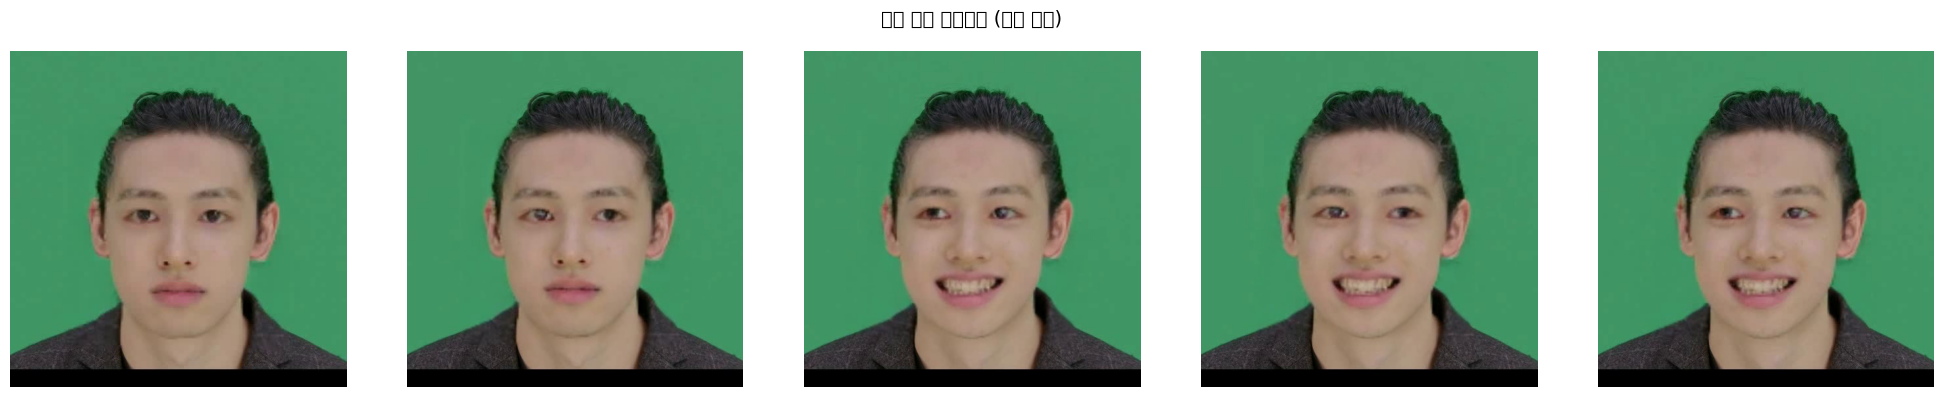


📥 결과 영상 다운로드


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# 결과 영상 몇 프레임 미리보기
preview_cap = cv2.VideoCapture(OUTPUT_VIDEO)
preview_frames = []
step = max(1, total_frames // 5)

for fi in [0, step, step*2, step*3, step*4]:
    preview_cap.set(cv2.CAP_PROP_POS_FRAMES, fi)
    ret, f = preview_cap.read()
    if ret:
        preview_frames.append(f)
preview_cap.release()

if preview_frames:
    fig, axes = plt.subplots(1, len(preview_frames), figsize=(20, 4))
    for ax, img in zip(axes, preview_frames):
        ax.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
        ax.axis('off')
    plt.suptitle('결과 영상 미리보기 (균등 샘플)', fontsize=14)
    plt.tight_layout()
    plt.show()

print('\n📥 결과 영상 다운로드')
files.download(OUTPUT_VIDEO)